## **HW1 Submission for Rhema Phiri**

In [195]:
# loading dataset
!curl -L -O https://github.com/mosesyhc/de300-2026sp/raw/refs/heads/main/homework/T_F41SCHEDULE_B43_with_missing.zip


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 1577k  100 1577k    0     0  1959k      0 --:--:-- --:--:-- --:--:-- 19.3M


In [196]:
# reading csv and importing all libraries
import pandas as pd
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
import scipy.stats as sps
import numpy as np
from sklearn.preprocessing import LabelEncoder

#!pip install --upgrade miceforest plotnine
import miceforest as mf

inventory = pd.read_csv('T_F41SCHEDULE_B43_with_missing.zip')

/tmp/ipykernel_22610/1195631724.py:15: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  inventory = pd.read_csv('T_F41SCHEDULE_B43_with_missing.zip')


## 1. **Investigating Missingness**







In [212]:
print(inventory.shape)
inventory.head(15)

(132313, 17)


,YEAR,CARRIER,CARRIER_NAME,MANUFACTURE_YEAR,UNIQUE_CARRIER_NAME,SERIAL_NUMBER,TAIL_NUMBER,AIRCRAFT_STATUS,OPERATING_STATUS,NUMBER_OF_SEATS,MANUFACTURER,AIRCRAFT_TYPE,MODEL,CAPACITY_IN_POUNDS,ACQUISITION_DATE,AIRLINE_ID,UNIQUE_CARRIER
0,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7858,N202PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,10/28/2003 12:00:00 AM,20397.0,16
1,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7860,N206PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,10/30/2003 12:00:00 AM,20397.0,16
2,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7873,N207PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,11/26/2003 12:00:00 AM,20397.0,16
3,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7874,N209PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,12/4/2003 12:00:00 AM,20397.0,16
4,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7879,N213PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,12/16/2003 12:00:00 AM,20397.0,16
5,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7880,N215PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,12/16/2003 12:00:00 AM,20397.0,16
6,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7882,N216PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,12/18/2003 12:00:00 AM,20397.0,16
7,2006,16,PSA Airlines Inc.,2004.0,PSA Airlines Inc.,10135,N702PS,B,Y,70.0,CANADAIR,NaN,RJ-700,67000.0,3/23/2004 12:00:00 AM,20397.0,16
8,2006,16,PSA Airlines Inc.,2004.0,PSA Airlines Inc.,10137,N703PS,B,Y,70.0,CANADAIR,NaN,RJ-700,67000.0,3/26/2004 12:00:00 AM,20397.0,16
9,2006,16,PSA Airlines Inc.,2004.0,PSA Airlines Inc.,10144,N705PS,B,Y,70.0,CANADAIR,NaN,RJ-700,67000.0,4/30/2004 12:00:00 AM,20397.0,16


<Axes: >

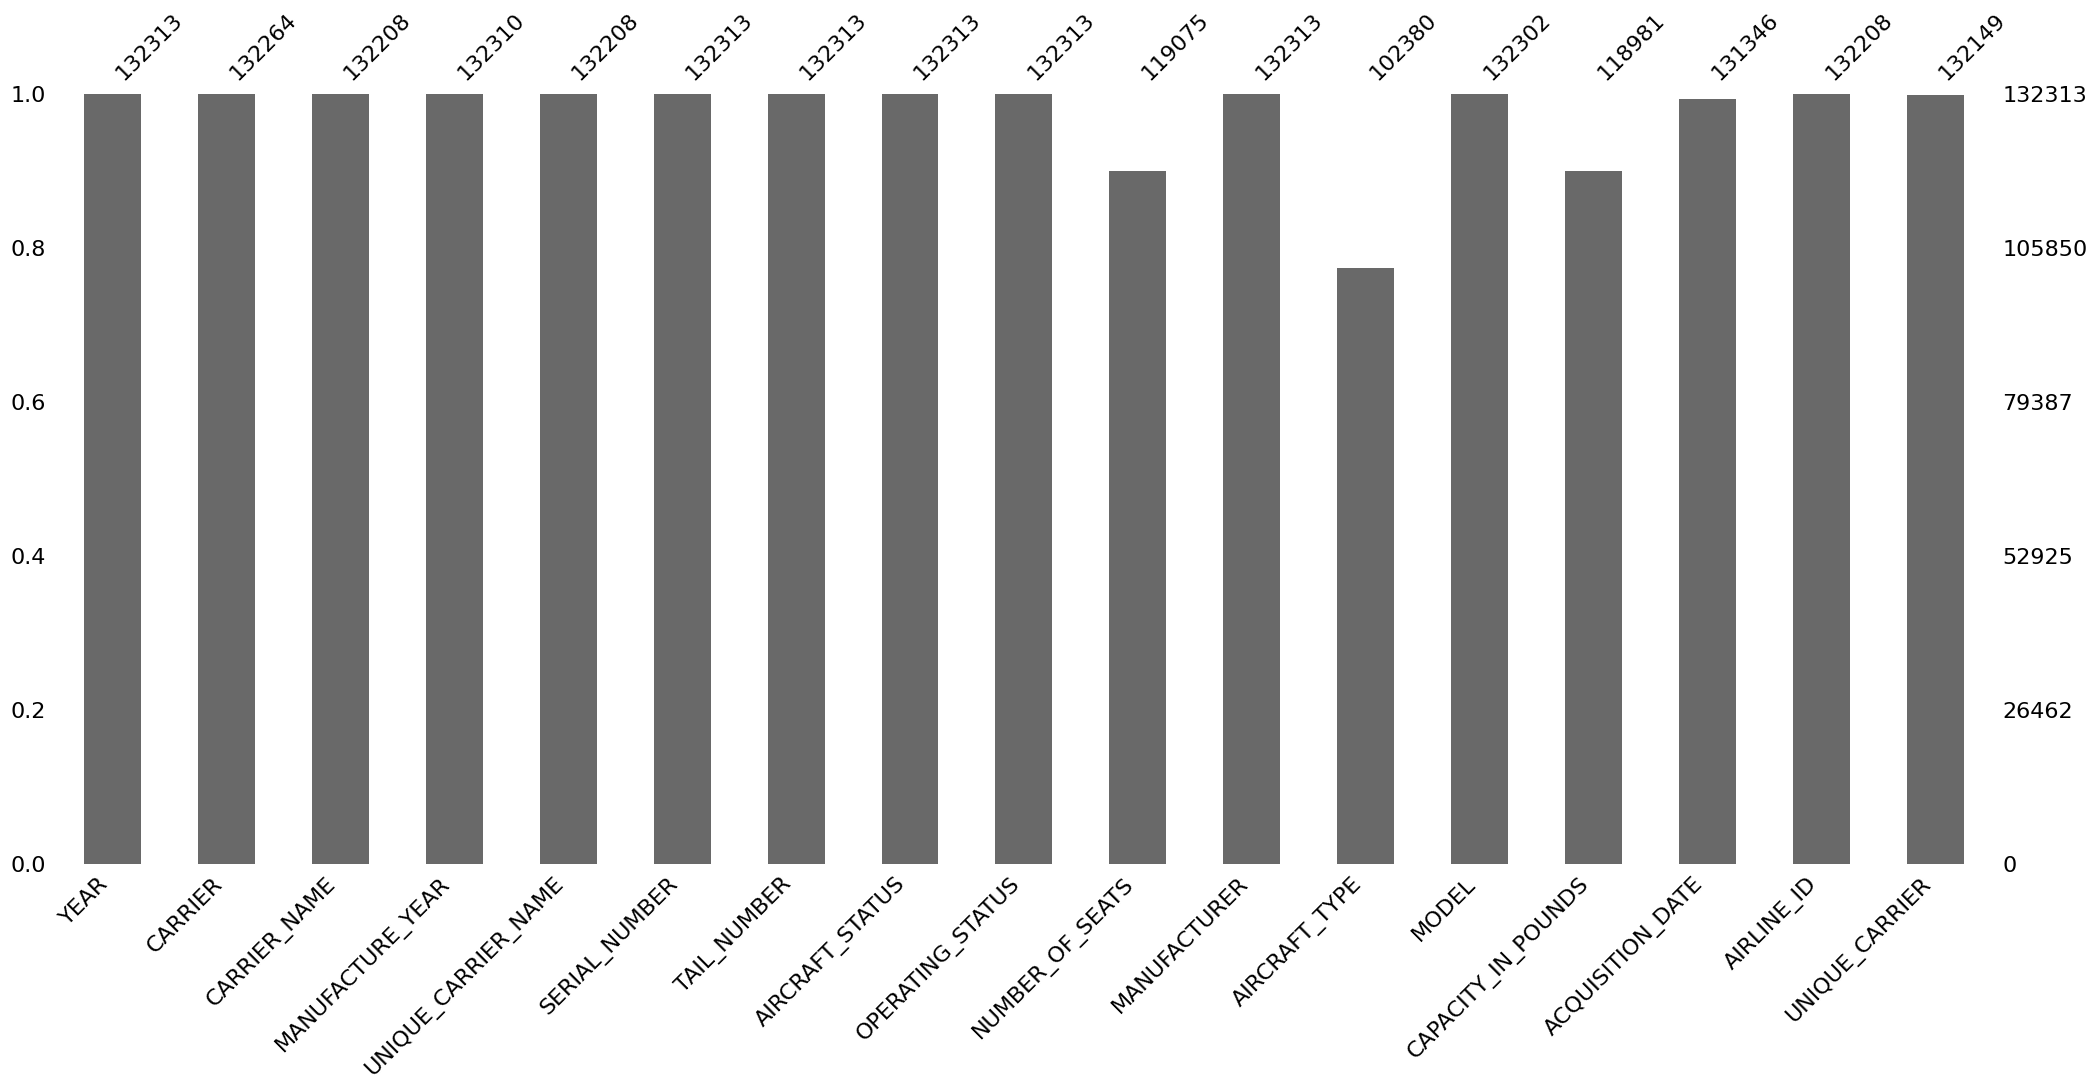

In [213]:
# visualization of available/missing data
# FOCUS : Missing Data in CARRIER, CARRIER_NAME, MANUFACTURE YEAR, NUMBER_OF_SEATS, CAPACITY_IN_POUNTDS AND AIRLINE_ID
msno.bar(inventory)

In [214]:
# Find the rows where CARRIER is genuinely null
null_carrier_filled_name = inventory[(inventory['CARRIER'].isnull()) & (inventory['CARRIER_NAME'].notna())]
null_carrier_filled_name[['CARRIER', 'CARRIER_NAME']].drop_duplicates()


,CARRIER,CARRIER_NAME
11776,NaN,North American Airlines


In [215]:
# Reverse to investigate CARRIER NAME
carrier_null_name = inventory[(inventory['CARRIER'].notna()) & (inventory['CARRIER_NAME'].isnull())]
carrier_null_name[['CARRIER', 'CARRIER_NAME']].drop_duplicates()

,CARRIER,CARRIER_NAME
11465,L4,NaN
54610,OH,NaN


In [242]:
# FUNCTION 1:
def cleaning_carrier_and_name(dataset):

  dataset.loc[dataset['CARRIER_NAME'] == 'North American Airlines', 'CARRIER'] = 'NA'
  dataset.loc[dataset['UNIQUE_CARRIER_NAME'] == 'North American Airlines', 'UNIQUE_CARRIER'] = 'NA'

  dataset.loc[(dataset['CARRIER'] == 'L4') & (dataset['CARRIER_NAME'].isna()), 'CARRIER_NAME'] = 'Lynx Aviation d/b/a Frontier Airlines'

  # after state
  missing = dataset[dataset['CARRIER_NAME'].isna() | dataset['CARRIER'].isna()]
  display(missing[['CARRIER', 'CARRIER_NAME']].drop_duplicates())
  return dataset


In [241]:
cleaning_carrier_and_name(inventory)

,CARRIER,CARRIER_NAME
54610,OH,NaN


,YEAR,CARRIER,CARRIER_NAME,MANUFACTURE_YEAR,UNIQUE_CARRIER_NAME,SERIAL_NUMBER,TAIL_NUMBER,AIRCRAFT_STATUS,OPERATING_STATUS,NUMBER_OF_SEATS,MANUFACTURER,AIRCRAFT_TYPE,MODEL,CAPACITY_IN_POUNDS,ACQUISITION_DATE,AIRLINE_ID,UNIQUE_CARRIER
0,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7858,N202PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,10/28/2003 12:00:00 AM,20397.0,16
1,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7860,N206PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,10/30/2003 12:00:00 AM,20397.0,16
2,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7873,N207PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,11/26/2003 12:00:00 AM,20397.0,16
3,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7874,N209PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,12/4/2003 12:00:00 AM,20397.0,16
4,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7879,N213PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,12/16/2003 12:00:00 AM,20397.0,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132308,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7899,N466AW,O,Y,50.0,Bombardier,6291,CL-600-2B19,NaN,1/21/2004 12:00:00 AM,20046.0,ZW
132309,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7900,N467AW,O,Y,50.0,Bombardier,6291,CL-600-2B19,NaN,1/23/2004 12:00:00 AM,20046.0,ZW
132310,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7916,N468AW,O,Y,50.0,Bombardier,6291,CL-600-2B19,NaN,3/25/2004 12:00:00 AM,20046.0,ZW
132311,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7917,N469AW,O,Y,50.0,Bombardier,6291,CL-600-2B19,NaN,3/18/2004 12:00:00 AM,20046.0,ZW


In [250]:
# Airline ID investigation
missing_airline_id = inventory[inventory['AIRLINE_ID'].isna()]
print(missing_airline_id[['CARRIER']].value_counts())


CARRIER
OH         97
Name: count, dtype: int64


In [251]:
# FUNCTION 2:
# build lookup from non-missing rows
def airline_id_missing(dataset):
  lookup = dataset.dropna(subset=['AIRLINE_ID']).groupby('CARRIER_NAME')['AIRLINE_ID'].first()

# fill missing AIRLINE_ID where CARRIER_NAME is known
  mask = dataset['AIRLINE_ID'].isna() & dataset['CARRIER_NAME'].notna()
  dataset.loc[mask, 'AIRLINE_ID'] = dataset.loc[mask, 'CARRIER_NAME'].map(lookup)

  missing = dataset[dataset['AIRLINE_ID'].isna()]
  display(missing[['CARRIER', 'CARRIER_NAME', 'AIRLINE_ID']].value_counts())
  return dataset

In [252]:
airline_id_missing(inventory)

,,,count
CARRIER,CARRIER_NAME,AIRLINE_ID,


,YEAR,CARRIER,CARRIER_NAME,MANUFACTURE_YEAR,UNIQUE_CARRIER_NAME,SERIAL_NUMBER,TAIL_NUMBER,AIRCRAFT_STATUS,OPERATING_STATUS,NUMBER_OF_SEATS,MANUFACTURER,AIRCRAFT_TYPE,MODEL,CAPACITY_IN_POUNDS,ACQUISITION_DATE,AIRLINE_ID,UNIQUE_CARRIER
0,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7858,N202PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,10/28/2003 12:00:00 AM,20397.0,16
1,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7860,N206PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,10/30/2003 12:00:00 AM,20397.0,16
2,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7873,N207PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,11/26/2003 12:00:00 AM,20397.0,16
3,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7874,N209PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,12/4/2003 12:00:00 AM,20397.0,16
4,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7879,N213PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,12/16/2003 12:00:00 AM,20397.0,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132308,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7899,N466AW,O,Y,50.0,Bombardier,6291,CL-600-2B19,NaN,1/21/2004 12:00:00 AM,20046.0,ZW
132309,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7900,N467AW,O,Y,50.0,Bombardier,6291,CL-600-2B19,NaN,1/23/2004 12:00:00 AM,20046.0,ZW
132310,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7916,N468AW,O,Y,50.0,Bombardier,6291,CL-600-2B19,NaN,3/25/2004 12:00:00 AM,20046.0,ZW
132311,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7917,N469AW,O,Y,50.0,Bombardier,6291,CL-600-2B19,NaN,3/18/2004 12:00:00 AM,20046.0,ZW


In [253]:
# FUNCTION 3: Testing Imputation Methods for num_seats and capacity_in_pounds
def imputation_methods_and_rmse(dataset, col_name):

  complete = dataset[dataset[col_name].notna()].copy().reset_index(drop=True)
  np.random.seed(42)
  mask = np.random.rand(len(complete)) < 0.2
  masked_indices = complete[mask].index
  true_values = complete.loc[masked_indices, col_name].copy()
  complete.loc[masked_indices, col_name] = np.nan

  # MEAN IMPUTER
  mean_imputer = SimpleImputer(strategy='mean')
  inventory_mean = complete.copy()
  inventory_mean[col_name] = mean_imputer.fit_transform(complete[[col_name]])

  # MEDIAN IMPUTER
  median_imputer = SimpleImputer(strategy='median')
  inventory_median = complete.copy()
  inventory_median[col_name] = median_imputer.fit_transform(complete[[col_name]])

  # KNN IMPUTER
  inventory_knn = complete.select_dtypes('number').copy()
  knn_imputer = KNNImputer(n_neighbors=3)
  inventory_knn_impute = knn_imputer.fit_transform(inventory_knn)
  inventory_knn_df = pd.DataFrame(inventory_knn_impute, columns=inventory_knn.columns, index=complete.index)

  # PREDICTIVE MEAN MATCHING
  inventory_kernel_pmm = mf.ImputationKernel(
    data=complete.select_dtypes('number'),
    num_datasets=5,
    mean_match_candidates=5,
    random_state=1,
    save_all_iterations_data=False)

  inventory_kernel_pmm.mice(iterations=10)
  inventory_kernel_pmm.tune_parameters()
  inventory_pmm = inventory_kernel_pmm.complete_data

  # RMSE CALCULATION:
  from sklearn.metrics import mean_squared_error

  imputation_methods = {
      'Mean':    inventory_mean,
      'Median':  inventory_median,
      'K-Nearest Neighbours':     inventory_knn_df}

  for name, df in imputation_methods.items():
    preds = df.loc[masked_indices, col_name]
    rmse = np.sqrt(mean_squared_error(true_values, preds))
    print(f"{name}: RMSE: {rmse:.4f}")

  pmm_rmses = []
  for i in range(5):
      pmm_df = inventory_kernel_pmm.complete_data(dataset=i)
      preds = pmm_df.loc[masked_indices, col_name]
      rmse = np.sqrt(mean_squared_error(true_values, preds))
      pmm_rmses.append(rmse)

  print(f"PMM mean RMSE across 5 datasets: {np.mean(pmm_rmses):.4f}")
  print(f"PMM std across 5 datasets:       {np.std(pmm_rmses):.4f}")

In [254]:
imputation_results_num_of_seats = imputation_methods_and_rmse(inventory, 'NUMBER_OF_SEATS') # Found that KNN was most appropriate because it has the lowest RMSE
imputation_results_cap_in_pounds = imputation_methods_and_rmse(inventory, 'CAPACITY_IN_POUNDS') # Found that PMM was most appropriate because it has the lowest RMSE

Mean: RMSE: 63.2934
Median: RMSE: 63.8415
K-Nearest Neighbours: RMSE: 8.3563
PMM mean RMSE across 5 datasets: 12.5851
PMM std across 5 datasets:       0.4651
Mean: RMSE: 83860.6242
Median: RMSE: 87949.6576
K-Nearest Neighbours: RMSE: 70418.8250
PMM mean RMSE across 5 datasets: 59385.4684
PMM std across 5 datasets:       1699.2300


In [256]:
# FUNCTION 4: Performing imputation on columns using best method
def imputate_and_missingness_investigation(dataset):
  # Performing these best method of imputation from above as a result!

  # NUMBER_OF_SEATS:
  inventory_knn = inventory.select_dtypes('number').copy()
  knn_imputer = KNNImputer(n_neighbors=3)
  inventory_knn_impute = knn_imputer.fit_transform(inventory_knn)
  inventory_knn_df = pd.DataFrame(inventory_knn_impute, columns=inventory_knn.columns,index=inventory.index)

  inventory['NUMBER_OF_SEATS'] = inventory_knn_df['NUMBER_OF_SEATS']

  #CAPACITY_IN_POUNDS:

  inventory_kernel_pmm = mf.ImputationKernel(
    data=inventory.select_dtypes('number').reset_index(drop=True),
    num_datasets=5,
    mean_match_candidates=5,
    random_state=1,
    save_all_iterations_data=False,
    variable_schema=['CAPACITY_IN_POUNDS'])

  inventory_kernel_pmm.tune_parameters()
  inventory_kernel_pmm.mice(iterations=10)
  inventory_pmm_df = inventory_kernel_pmm.complete_data(dataset=0)
  inventory['CAPACITY_IN_POUNDS'] = inventory_pmm_df['CAPACITY_IN_POUNDS'].values
  return dataset

In [257]:
imputate_and_missingness_investigation(inventory)

,YEAR,CARRIER,CARRIER_NAME,MANUFACTURE_YEAR,UNIQUE_CARRIER_NAME,SERIAL_NUMBER,TAIL_NUMBER,AIRCRAFT_STATUS,OPERATING_STATUS,NUMBER_OF_SEATS,MANUFACTURER,AIRCRAFT_TYPE,MODEL,CAPACITY_IN_POUNDS,ACQUISITION_DATE,AIRLINE_ID,UNIQUE_CARRIER
0,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7858,N202PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,10/28/2003 12:00:00 AM,20397.0,16
1,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7860,N206PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,10/30/2003 12:00:00 AM,20397.0,16
2,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7873,N207PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,11/26/2003 12:00:00 AM,20397.0,16
3,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7874,N209PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,12/4/2003 12:00:00 AM,20397.0,16
4,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7879,N213PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,12/16/2003 12:00:00 AM,20397.0,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132308,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7899,N466AW,O,Y,50.0,Bombardier,6291,CL-600-2B19,12972.0,1/21/2004 12:00:00 AM,20046.0,ZW
132309,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7900,N467AW,O,Y,50.0,Bombardier,6291,CL-600-2B19,12972.0,1/23/2004 12:00:00 AM,20046.0,ZW
132310,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7916,N468AW,O,Y,50.0,Bombardier,6291,CL-600-2B19,12972.0,3/25/2004 12:00:00 AM,20046.0,ZW
132311,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7917,N469AW,O,Y,50.0,Bombardier,6291,CL-600-2B19,12972.0,3/18/2004 12:00:00 AM,20046.0,ZW


In [258]:
inventory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132313 entries, 0 to 132312
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   YEAR                 132313 non-null  int64  
 1   CARRIER              132313 non-null  object 
 2   CARRIER_NAME         132216 non-null  object 
 3   MANUFACTURE_YEAR     132310 non-null  float64
 4   UNIQUE_CARRIER_NAME  132208 non-null  object 
 5   SERIAL_NUMBER        132313 non-null  object 
 6   TAIL_NUMBER          132313 non-null  object 
 7   AIRCRAFT_STATUS      132313 non-null  object 
 8   OPERATING_STATUS     132313 non-null  object 
 9   NUMBER_OF_SEATS      132313 non-null  float64
 10  MANUFACTURER         132313 non-null  object 
 11  AIRCRAFT_TYPE        102380 non-null  object 
 12  MODEL                132302 non-null  object 
 13  CAPACITY_IN_POUNDS   132313 non-null  float64
 14  ACQUISITION_DATE     131346 non-null  object 
 15  AIRLINE_ID       

## **2. Standardization and Transformation**

In [259]:
# FUNCTION 5: Standardizing OP Status
def standardizing_operating_status(dataset):
  dataset['OPERATING_STATUS'] = dataset['OPERATING_STATUS'].str.strip().str.upper()
  dataset['OPERATING_STATUS'] = dataset['OPERATING_STATUS'].replace('', np.nan)

  print(dataset['OPERATING_STATUS'].value_counts(dropna=False))
  return dataset

In [260]:
standardizing_operating_status(inventory)

OPERATING_STATUS
Y      126648
N        5664
NaN         1
Name: count, dtype: int64


,YEAR,CARRIER,CARRIER_NAME,MANUFACTURE_YEAR,UNIQUE_CARRIER_NAME,SERIAL_NUMBER,TAIL_NUMBER,AIRCRAFT_STATUS,OPERATING_STATUS,NUMBER_OF_SEATS,MANUFACTURER,AIRCRAFT_TYPE,MODEL,CAPACITY_IN_POUNDS,ACQUISITION_DATE,AIRLINE_ID,UNIQUE_CARRIER
0,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7858,N202PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,10/28/2003 12:00:00 AM,20397.0,16
1,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7860,N206PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,10/30/2003 12:00:00 AM,20397.0,16
2,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7873,N207PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,11/26/2003 12:00:00 AM,20397.0,16
3,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7874,N209PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,12/4/2003 12:00:00 AM,20397.0,16
4,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7879,N213PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,12/16/2003 12:00:00 AM,20397.0,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132308,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7899,N466AW,O,Y,50.0,Bombardier,6291,CL-600-2B19,12972.0,1/21/2004 12:00:00 AM,20046.0,ZW
132309,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7900,N467AW,O,Y,50.0,Bombardier,6291,CL-600-2B19,12972.0,1/23/2004 12:00:00 AM,20046.0,ZW
132310,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7916,N468AW,O,Y,50.0,Bombardier,6291,CL-600-2B19,12972.0,3/25/2004 12:00:00 AM,20046.0,ZW
132311,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7917,N469AW,O,Y,50.0,Bombardier,6291,CL-600-2B19,12972.0,3/18/2004 12:00:00 AM,20046.0,ZW


In [261]:
# FUNCTION 6: Standardizing Aircraft Status
def standardizing_aircraft_status(dataset):
  dataset['AIRCRAFT_STATUS'] = dataset['AIRCRAFT_STATUS'].str.strip().str.upper()
  print(dataset['AIRCRAFT_STATUS'].value_counts(dropna=False))
  return dataset

In [262]:
standardizing_aircraft_status(inventory)

AIRCRAFT_STATUS
O    79506
B    43551
A     9134
L      122
Name: count, dtype: int64


,YEAR,CARRIER,CARRIER_NAME,MANUFACTURE_YEAR,UNIQUE_CARRIER_NAME,SERIAL_NUMBER,TAIL_NUMBER,AIRCRAFT_STATUS,OPERATING_STATUS,NUMBER_OF_SEATS,MANUFACTURER,AIRCRAFT_TYPE,MODEL,CAPACITY_IN_POUNDS,ACQUISITION_DATE,AIRLINE_ID,UNIQUE_CARRIER
0,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7858,N202PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,10/28/2003 12:00:00 AM,20397.0,16
1,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7860,N206PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,10/30/2003 12:00:00 AM,20397.0,16
2,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7873,N207PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,11/26/2003 12:00:00 AM,20397.0,16
3,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7874,N209PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,12/4/2003 12:00:00 AM,20397.0,16
4,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7879,N213PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,12/16/2003 12:00:00 AM,20397.0,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132308,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7899,N466AW,O,Y,50.0,Bombardier,6291,CL-600-2B19,12972.0,1/21/2004 12:00:00 AM,20046.0,ZW
132309,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7900,N467AW,O,Y,50.0,Bombardier,6291,CL-600-2B19,12972.0,1/23/2004 12:00:00 AM,20046.0,ZW
132310,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7916,N468AW,O,Y,50.0,Bombardier,6291,CL-600-2B19,12972.0,3/25/2004 12:00:00 AM,20046.0,ZW
132311,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7917,N469AW,O,Y,50.0,Bombardier,6291,CL-600-2B19,12972.0,3/18/2004 12:00:00 AM,20046.0,ZW


In [264]:
# FUNCTION 7: Standardizing Manufacturer
def standardizing_manufacturer(dataset):
  dataset['MANUFACTURER'] = dataset['MANUFACTURER'].str.strip()

  manufacturer_mapping = {
    'BOEING': ['B757-223','Boeing', 'boeing', 'BOEINGCO', 'BoeingCo', 'BoeingCo.',
               'THEBOEINGCO', 'THEBOEINGCOMPANY', 'TheBoeingCompany',
               'Boeing(McDonnell-Douglas)', 'BOEINGCOMPANY', 'TheBOEINGCO', 'Boeing747-446'],

    'AIRBUS': ['Airbus', 'airbus', 'AIRBUSINDUSTRIES', 'AirbusIndustrie',
               'AirbusIndustries', 'AirbusCompany', 'AirBlue/Airbus'],

    'MCDONNELL DOUGLAS': ['MCDONNELL-DOUGLAS', 'MCDONNELLDOUGLAS', 'McDonnellDouglas',
                      'McDonaldDouglas', 'McDonnelDouglas', 'MCDONNEL', 'MCDONNELLDOUG',
                      'MDDouglas', 'MCDO', 'MCDONNELL', 'McDonnell-Douglas',
                      'McDonnellDouglasMD11-F', 'DOUGLASAIRCRAFT', 'DOUGLAS', 'Douglas'],

    'BOMBARDIER': ['Bombardier', 'BombardierAerospace', 'CANADAIR', 'Canadair',
               'CHALLENGER', 'Challenger', 'Challenger300', 'GLOBALEXP'],

    'EMBRAER': ['Embraer'],

    'GULFSTREAM': ['Gulfstream', 'GULFSTREAMAEROSPACE', 'GULFSTREAMAEROSPACECORP'],

    'DASSAULT': ['Dassault', 'DASSAULT/SUD', 'Dassault/SUD', 'DASSULT SUD',
             'Dassault-Falcon-2000EXEASy'],

    'SAAB': ['Saab', 'SAAB AIRCRAFT', 'SAAB-Fairchild', 'SAABFairchild', 'SAABScania'],

    'DE HAVILLAND': ['DEHAVILLAND', 'DeHavilland', 'deHavilland'],

    'FOKKER': ['FOKKER70', 'FOKKER71', 'FOKKER72', 'FOKKERAIRCRAFTUSA'],

    'LOCKHEED': ['Lockheed'],

    'BEECHCRAFT': ['BEECHHAWKER400XP'],

    'LEARJET': ['LEAR', 'Learjet', 'LearjetInc', 'GATESLEARJET'],

    'RAYTHEON': ['Raetheon', 'Raytheon'],

    'IAI': ['IAILTD', 'ISRAELAIRCRAFTINDUSTRIES'],

    'PIPER': ['Piper'],

    'DORNIER' : ['Dornier'],

    'EASYJET' : ['easyJet/BBAM', 'easyJet/Fuyo', 'easyJet/GECAS', 'easyJet/GOAL', 'easyJet/Investec', 'CBA/EASYJET', 'CBA/easyJet'],

    'VUELIING' : ['Vueling/Aercap', 'Vueling/GECAS'],

    'ALC' : ['ALC/Alaska'],

    'SMBC': ['SMBC/Sky', 'SMBCAviationCapitalLimited'],

    'JPLEASE' : ['JPLEASE/CEBUPACIFIC', 'JPLease/AerLingus', 'JPLease/CebuPacific','JPLease/Peach' ],

    'IBERIA' : ['Iberia/ILFC', 'Iberia/MCAP', 'Iberia/SMBC' ],

    'GE' : ['GECAS', 'GECAS/Alaska', 'GECOMMERCIALAVIATIONSERVICES'],

    'CEBUPACIFIC' : ['CebuPacific', 'CebuPacific/JPLease', 'CebuPacific/SMBC'],

    'AERCAP' : ['AerCap','Aercap/Frontier'],

    'AVOLON': ['Avolon', 'Avolon/Peach'],

    'FGLAIRCRAFT' :['FGLAIRCAFT/PEACH']

  }

  flipped = {old: new for new, olds in manufacturer_mapping.items() for old in olds}
  dataset['MANUFACTURER'] = dataset['MANUFACTURER'].replace(flipped)
  dataset['MANUFACTURER'] = dataset['MANUFACTURER'].str.upper()


  print(dataset['MANUFACTURER'].value_counts(dropna=False))
  return dataset

In [265]:
standardizing_manufacturer(inventory)

MANUFACTURER
BOEING               55640
AIRBUS               23517
BOMBARDIER           16386
EMBRAER              15554
MCDONNELL DOUGLAS    10812
                     ...  
CDBA/CEBUPACIFIC         2
ROLLS-ROYCE              1
CSSNACITATIONX           1
AMA/EXPR                 1
JSA/PEACH                1
Name: count, Length: 67, dtype: int64


,YEAR,CARRIER,CARRIER_NAME,MANUFACTURE_YEAR,UNIQUE_CARRIER_NAME,SERIAL_NUMBER,TAIL_NUMBER,AIRCRAFT_STATUS,OPERATING_STATUS,NUMBER_OF_SEATS,MANUFACTURER,AIRCRAFT_TYPE,MODEL,CAPACITY_IN_POUNDS,ACQUISITION_DATE,AIRLINE_ID,UNIQUE_CARRIER
0,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7858,N202PS,B,Y,50.0,BOMBARDIER,NaN,CRJ-2/4,47000.0,10/28/2003 12:00:00 AM,20397.0,16
1,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7860,N206PS,B,Y,50.0,BOMBARDIER,NaN,CRJ-2/4,47000.0,10/30/2003 12:00:00 AM,20397.0,16
2,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7873,N207PS,B,Y,50.0,BOMBARDIER,NaN,CRJ-2/4,47000.0,11/26/2003 12:00:00 AM,20397.0,16
3,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7874,N209PS,B,Y,50.0,BOMBARDIER,NaN,CRJ-2/4,47000.0,12/4/2003 12:00:00 AM,20397.0,16
4,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7879,N213PS,B,Y,50.0,BOMBARDIER,NaN,CRJ-2/4,47000.0,12/16/2003 12:00:00 AM,20397.0,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132308,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7899,N466AW,O,Y,50.0,BOMBARDIER,6291,CL-600-2B19,12972.0,1/21/2004 12:00:00 AM,20046.0,ZW
132309,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7900,N467AW,O,Y,50.0,BOMBARDIER,6291,CL-600-2B19,12972.0,1/23/2004 12:00:00 AM,20046.0,ZW
132310,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7916,N468AW,O,Y,50.0,BOMBARDIER,6291,CL-600-2B19,12972.0,3/25/2004 12:00:00 AM,20046.0,ZW
132311,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7917,N469AW,O,Y,50.0,BOMBARDIER,6291,CL-600-2B19,12972.0,3/18/2004 12:00:00 AM,20046.0,ZW


In [266]:
# FUNCTION 8: Standardizing Model
def standardizing_model(dataset):
  dataset['MODEL'] = dataset['MODEL'].str.strip()

  model_mapping = {
    'B737': ['B-737-7H4','B737-823', 'B737-800PAX', 'B737-7/L', 'B-737-8H4', 'B737-3',
               'B737-823PASSENGER', 'B737-8', '737-832-PSGR', 'B737-900ERPAX','737-700PASSENGERONLY', 'B737-890ALLPAX', '737-300PASSENGERONLY',
             'B737-990ERALLPAX'],

    'CRJ': ['CRJ-2/4', 'CRJ200-2B19', 'CRJ-200', 'CRJ-900LR-PSGR', 'CRJ-700', 'CRJ-200-PSGR','CRJ-900-PSGR', 'CRJ200', 'CRJ700-2C10',
            'CRJ900', 'CRJ-900'],

    'A320' : ['A320-232', 'A320-1/2', 'A320', 'A-320-PSGR', 'AirbusA320-232', 'A320-214'],

    'A319' : ['A319', 'A319-112', 'A319-114-PSGR', 'A319-132'],

    'B757' : ['B757-2','757-200', '757-24APF', '757-232-PSGR'],

    'MD-80' : ['MD-80', 'SUPER80PASSENGER', 'MD-88-PSGR'],

    'ERJ' : ['ERJ-170-200LR', 'ERJ-175', 'ERJ-145LR']
  }

  flipped = {old: new for new, olds in model_mapping.items() for old in olds}
  dataset['MODEL'] = dataset['MODEL'].replace(flipped)

  dataset['MODEL'] = dataset['MODEL'].replace('0', np.nan)
  print(inventory['MODEL'].value_counts(dropna=False).head(30))
  return dataset

In [268]:
standardizing_model(inventory)

MODEL
B737              17900
CRJ               10493
A320               6650
B757               5156
MD-80              3746
A319               3369
ERJ                3232
EMB-145            2976
A321-231           2259
C-208B             1872
MD-11              1107
C-208B/3           1017
RJ-700              906
EMB-140             841
717-200-PSGR        785
767-34AF            783
CE-208B             758
E190-100            735
A300F4-622R         731
NaN                 717
B767-3              690
CL65                682
A321-211            679
MD-11F              608
EMB-175-PSGR        596
B-757-2             594
DHC8-400            584
737-932ER-PSGR      575
A321-211-PSGR       569
737-7H4             569
Name: count, dtype: int64


,YEAR,CARRIER,CARRIER_NAME,MANUFACTURE_YEAR,UNIQUE_CARRIER_NAME,SERIAL_NUMBER,TAIL_NUMBER,AIRCRAFT_STATUS,OPERATING_STATUS,NUMBER_OF_SEATS,MANUFACTURER,AIRCRAFT_TYPE,MODEL,CAPACITY_IN_POUNDS,ACQUISITION_DATE,AIRLINE_ID,UNIQUE_CARRIER
0,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7858,N202PS,B,Y,50.0,BOMBARDIER,NaN,CRJ,47000.0,10/28/2003 12:00:00 AM,20397.0,16
1,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7860,N206PS,B,Y,50.0,BOMBARDIER,NaN,CRJ,47000.0,10/30/2003 12:00:00 AM,20397.0,16
2,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7873,N207PS,B,Y,50.0,BOMBARDIER,NaN,CRJ,47000.0,11/26/2003 12:00:00 AM,20397.0,16
3,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7874,N209PS,B,Y,50.0,BOMBARDIER,NaN,CRJ,47000.0,12/4/2003 12:00:00 AM,20397.0,16
4,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7879,N213PS,B,Y,50.0,BOMBARDIER,NaN,CRJ,47000.0,12/16/2003 12:00:00 AM,20397.0,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132308,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7899,N466AW,O,Y,50.0,BOMBARDIER,6291,CL-600-2B19,12972.0,1/21/2004 12:00:00 AM,20046.0,ZW
132309,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7900,N467AW,O,Y,50.0,BOMBARDIER,6291,CL-600-2B19,12972.0,1/23/2004 12:00:00 AM,20046.0,ZW
132310,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7916,N468AW,O,Y,50.0,BOMBARDIER,6291,CL-600-2B19,12972.0,3/25/2004 12:00:00 AM,20046.0,ZW
132311,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7917,N469AW,O,Y,50.0,BOMBARDIER,6291,CL-600-2B19,12972.0,3/18/2004 12:00:00 AM,20046.0,ZW


## **3. Removing Remaining Missing Data**

In [269]:
# FUNCTION 9: Dropping missing rows
def drop_remaining_missing_rows(dataset):
    rows_before = len(dataset)
    dataset = dataset.dropna()
    rows_after = len(dataset)
    print(f'Rows removed:   {rows_before - rows_after:,}')
    print(f'Rows remaining: {rows_after:,}')
    return dataset

In [270]:
drop_remaining_missing_rows(inventory)

Rows removed:   31,716
Rows remaining: 100,597


,YEAR,CARRIER,CARRIER_NAME,MANUFACTURE_YEAR,UNIQUE_CARRIER_NAME,SERIAL_NUMBER,TAIL_NUMBER,AIRCRAFT_STATUS,OPERATING_STATUS,NUMBER_OF_SEATS,MANUFACTURER,AIRCRAFT_TYPE,MODEL,CAPACITY_IN_POUNDS,ACQUISITION_DATE,AIRLINE_ID,UNIQUE_CARRIER
29239,2010,0JQ,Vision Airlines,1982.0,Vision Airlines,21866,N769VA,B,Y,92.0,BOEING,6251.0,B767-2-PSGR,68242.0,9/1/2007 12:00:00 AM,21236.0,0JQ
29240,2010,0JQ,Vision Airlines,1982.0,Vision Airlines,21869,N768VA,B,Y,86.0,BOEING,6251.0,B767-2-PSGR,69822.0,9/1/2007 12:00:00 AM,21236.0,0JQ
29241,2010,0JQ,Vision Airlines,1982.0,Vision Airlines,21870,N767VA,B,Y,86.0,BOEING,6251.0,B767-2-PSGR,66443.0,7/1/2007 12:00:00 AM,21236.0,0JQ
29242,2010,0JQ,Vision Airlines,1985.0,Vision Airlines,23366,N732VA,B,Y,136.0,BOEING,6191.0,B737-300-PSGR,32282.0,7/1/2008 12:00:00 AM,21236.0,0JQ
29243,2010,0JQ,Vision Airlines,1985.0,Vision Airlines,8044,N407VA,B,N,19.0,DORNIER,4481.0,DO-228-PSGR,0.0,12/1/2003 12:00:00 AM,21236.0,0JQ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132308,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7899,N466AW,O,Y,50.0,BOMBARDIER,6291,CL-600-2B19,12972.0,1/21/2004 12:00:00 AM,20046.0,ZW
132309,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7900,N467AW,O,Y,50.0,BOMBARDIER,6291,CL-600-2B19,12972.0,1/23/2004 12:00:00 AM,20046.0,ZW
132310,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7916,N468AW,O,Y,50.0,BOMBARDIER,6291,CL-600-2B19,12972.0,3/25/2004 12:00:00 AM,20046.0,ZW
132311,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7917,N469AW,O,Y,50.0,BOMBARDIER,6291,CL-600-2B19,12972.0,3/18/2004 12:00:00 AM,20046.0,ZW


## **4. Transformation and derivative variables**



NUMBER_OF_SEATS skewness: -0.3474991754111088
CAPACITY_IN_POUNDS skewness: 4.060419990700226


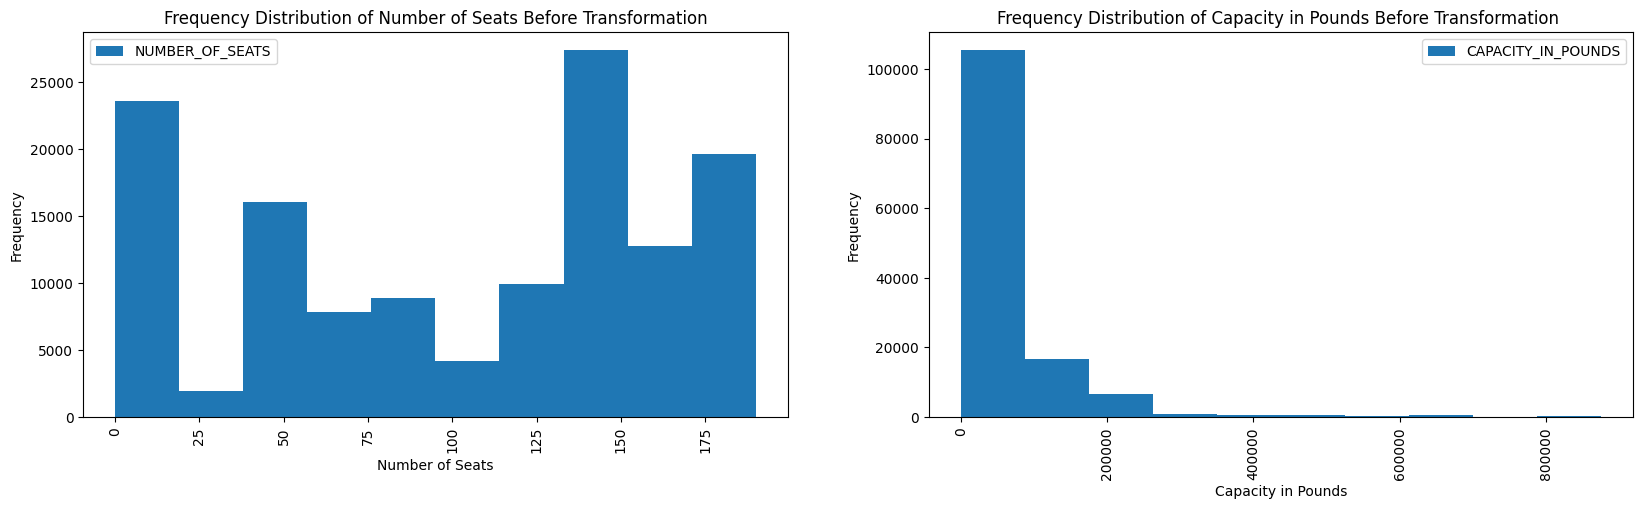

In [271]:
# For the columns NUMBER_OF_SEATS and CAPACITY_IN_POUNDS, check the skewness in the variable and plot a histogram for each variable.
print("NUMBER_OF_SEATS skewness:", inventory['NUMBER_OF_SEATS'].skew())
print("CAPACITY_IN_POUNDS skewness:", inventory['CAPACITY_IN_POUNDS'].skew())

fig, (ax1,ax2) = plt.subplots(1,2, figsize=(20,5))

# Histogram for Number Of Seats Variable
inventory.plot.hist(column='NUMBER_OF_SEATS', ax=ax1)
ax1.set_title('Frequency Distribution of Number of Seats Before Transformation')
ax1.set_xlabel('Number of Seats')
ax1.set_ylabel('Frequency')
ax1.tick_params(axis='x', rotation=90)

# Histogram for Capacity in Pounds Variable
inventory.plot.hist(column='CAPACITY_IN_POUNDS',ax = ax2)
ax2.set_title('Frequency Distribution of Capacity in Pounds Before Transformation ')
ax2.set_xlabel('Capacity in Pounds')
ax2.set_ylabel('Frequency')
ax2.tick_params(axis='x', rotation=90)

In [272]:
# FUNCTION 10: Box-Cox Transforming
def transformation(dataset):
  # Applying Box-Cox transformation to NUMBER_OF_SEATS and CAPACITY_IN_POUNDS and saving new columns

  #requires positive data
  seats_mask = dataset['NUMBER_OF_SEATS'] > 0
  dataset.loc[seats_mask, 'NUMBER_OF_SEATS_BOXCOX'] = sps.boxcox(dataset.loc[seats_mask, 'NUMBER_OF_SEATS'])[0]

  capacity_mask = dataset['CAPACITY_IN_POUNDS'] > 0
  dataset.loc[capacity_mask, 'CAPACITY_IN_POUNDS_BOXCOX'] = sps.boxcox(dataset.loc[capacity_mask, 'CAPACITY_IN_POUNDS'])[0]
  return dataset

In [273]:
transformation(inventory)

,YEAR,CARRIER,CARRIER_NAME,MANUFACTURE_YEAR,UNIQUE_CARRIER_NAME,SERIAL_NUMBER,TAIL_NUMBER,AIRCRAFT_STATUS,OPERATING_STATUS,NUMBER_OF_SEATS,MANUFACTURER,AIRCRAFT_TYPE,MODEL,CAPACITY_IN_POUNDS,ACQUISITION_DATE,AIRLINE_ID,UNIQUE_CARRIER,NUMBER_OF_SEATS_BOXCOX,CAPACITY_IN_POUNDS_BOXCOX
0,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7858,N202PS,B,Y,50.0,BOMBARDIER,NaN,CRJ,47000.0,10/28/2003 12:00:00 AM,20397.0,16,102.728513,28.894613
1,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7860,N206PS,B,Y,50.0,BOMBARDIER,NaN,CRJ,47000.0,10/30/2003 12:00:00 AM,20397.0,16,102.728513,28.894613
2,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7873,N207PS,B,Y,50.0,BOMBARDIER,NaN,CRJ,47000.0,11/26/2003 12:00:00 AM,20397.0,16,102.728513,28.894613
3,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7874,N209PS,B,Y,50.0,BOMBARDIER,NaN,CRJ,47000.0,12/4/2003 12:00:00 AM,20397.0,16,102.728513,28.894613
4,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7879,N213PS,B,Y,50.0,BOMBARDIER,NaN,CRJ,47000.0,12/16/2003 12:00:00 AM,20397.0,16,102.728513,28.894613
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132308,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7899,N466AW,O,Y,50.0,BOMBARDIER,6291,CL-600-2B19,12972.0,1/21/2004 12:00:00 AM,20046.0,ZW,102.728513,22.323021
132309,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7900,N467AW,O,Y,50.0,BOMBARDIER,6291,CL-600-2B19,12972.0,1/23/2004 12:00:00 AM,20046.0,ZW,102.728513,22.323021
132310,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7916,N468AW,O,Y,50.0,BOMBARDIER,6291,CL-600-2B19,12972.0,3/25/2004 12:00:00 AM,20046.0,ZW,102.728513,22.323021
132311,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7917,N469AW,O,Y,50.0,BOMBARDIER,6291,CL-600-2B19,12972.0,3/18/2004 12:00:00 AM,20046.0,ZW,102.728513,22.323021


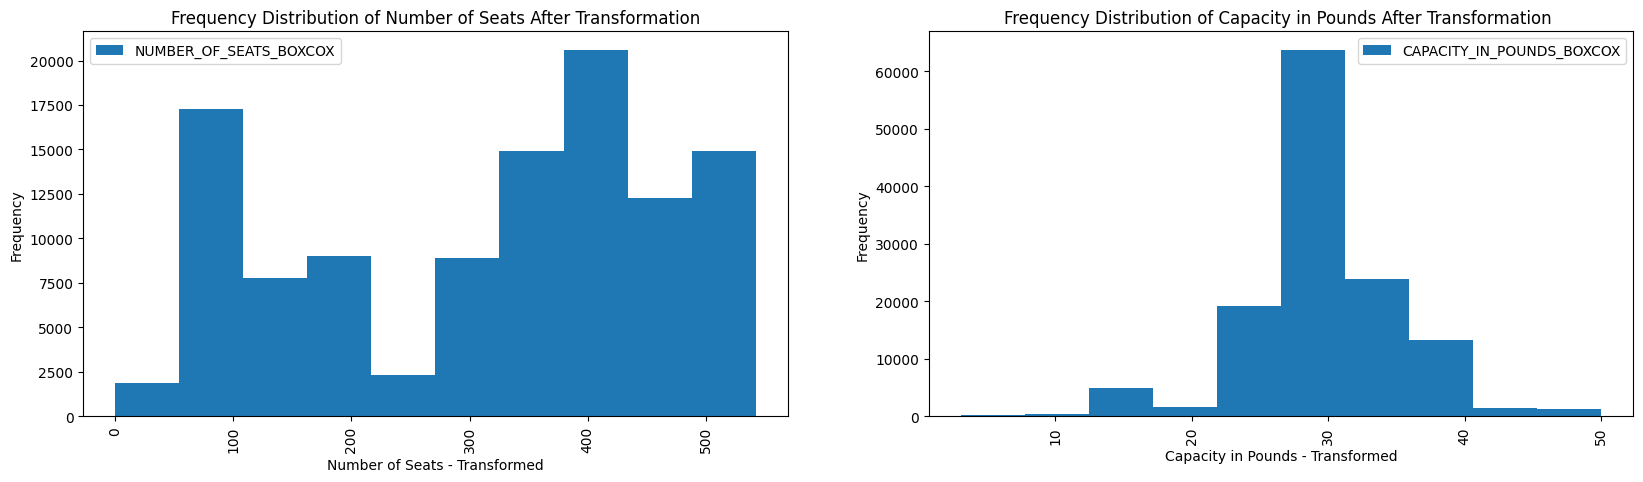

In [274]:
# Plotting after Transformation
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(20,5))

# Histogram for Number Of Seats Variable
inventory.plot.hist(column='NUMBER_OF_SEATS_BOXCOX', ax=ax1)
ax1.set_title('Frequency Distribution of Number of Seats After Transformation')
ax1.set_xlabel('Number of Seats - Transformed')
ax1.set_ylabel('Frequency')
ax1.tick_params(axis='x', rotation=90)

# Histogram for Capacity in Pounds Variable
inventory.plot.hist(column='CAPACITY_IN_POUNDS_BOXCOX',ax = ax2)
ax2.set_title('Frequency Distribution of Capacity in Pounds After Transformation ')
ax2.set_xlabel('Capacity in Pounds - Transformed')
ax2.set_ylabel('Frequency')
ax2.tick_params(axis='x', rotation=90)

# **5. Feature Engineering**

In [275]:
# FUNCTION 11: Creating Size Quartiles
def size_by_quartile (dataset):
  # Create a new column SIZE by the quartiles of NUMBER_OF_SEATS
  q1, q2, q3 = dataset['NUMBER_OF_SEATS'].quantile([0.25, 0.50, 0.75])
  dataset['SIZE'] = pd.qcut(dataset['NUMBER_OF_SEATS'],
                      q=4,
                      labels=['SMALL', 'MEDIUM', 'LARGE', 'XLARGE']).astype(str)
  print(inventory['SIZE']. value_counts())
  return dataset

In [276]:
size_by_quartile(inventory)

SIZE
SMALL     41597
LARGE     33343
XLARGE    32591
MEDIUM    24782
Name: count, dtype: int64


,YEAR,CARRIER,CARRIER_NAME,MANUFACTURE_YEAR,UNIQUE_CARRIER_NAME,SERIAL_NUMBER,TAIL_NUMBER,AIRCRAFT_STATUS,OPERATING_STATUS,NUMBER_OF_SEATS,MANUFACTURER,AIRCRAFT_TYPE,MODEL,CAPACITY_IN_POUNDS,ACQUISITION_DATE,AIRLINE_ID,UNIQUE_CARRIER,NUMBER_OF_SEATS_BOXCOX,CAPACITY_IN_POUNDS_BOXCOX,SIZE
0,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7858,N202PS,B,Y,50.0,BOMBARDIER,NaN,CRJ,47000.0,10/28/2003 12:00:00 AM,20397.0,16,102.728513,28.894613,SMALL
1,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7860,N206PS,B,Y,50.0,BOMBARDIER,NaN,CRJ,47000.0,10/30/2003 12:00:00 AM,20397.0,16,102.728513,28.894613,SMALL
2,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7873,N207PS,B,Y,50.0,BOMBARDIER,NaN,CRJ,47000.0,11/26/2003 12:00:00 AM,20397.0,16,102.728513,28.894613,SMALL
3,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7874,N209PS,B,Y,50.0,BOMBARDIER,NaN,CRJ,47000.0,12/4/2003 12:00:00 AM,20397.0,16,102.728513,28.894613,SMALL
4,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7879,N213PS,B,Y,50.0,BOMBARDIER,NaN,CRJ,47000.0,12/16/2003 12:00:00 AM,20397.0,16,102.728513,28.894613,SMALL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132308,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7899,N466AW,O,Y,50.0,BOMBARDIER,6291,CL-600-2B19,12972.0,1/21/2004 12:00:00 AM,20046.0,ZW,102.728513,22.323021,SMALL
132309,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7900,N467AW,O,Y,50.0,BOMBARDIER,6291,CL-600-2B19,12972.0,1/23/2004 12:00:00 AM,20046.0,ZW,102.728513,22.323021,SMALL
132310,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7916,N468AW,O,Y,50.0,BOMBARDIER,6291,CL-600-2B19,12972.0,3/25/2004 12:00:00 AM,20046.0,ZW,102.728513,22.323021,SMALL
132311,2023,ZW,Air Wisconsin Airlines Corp,2004.0,Air Wisconsin Airlines Corp,7917,N469AW,O,Y,50.0,BOMBARDIER,6291,CL-600-2B19,12972.0,3/18/2004 12:00:00 AM,20046.0,ZW,102.728513,22.323021,SMALL


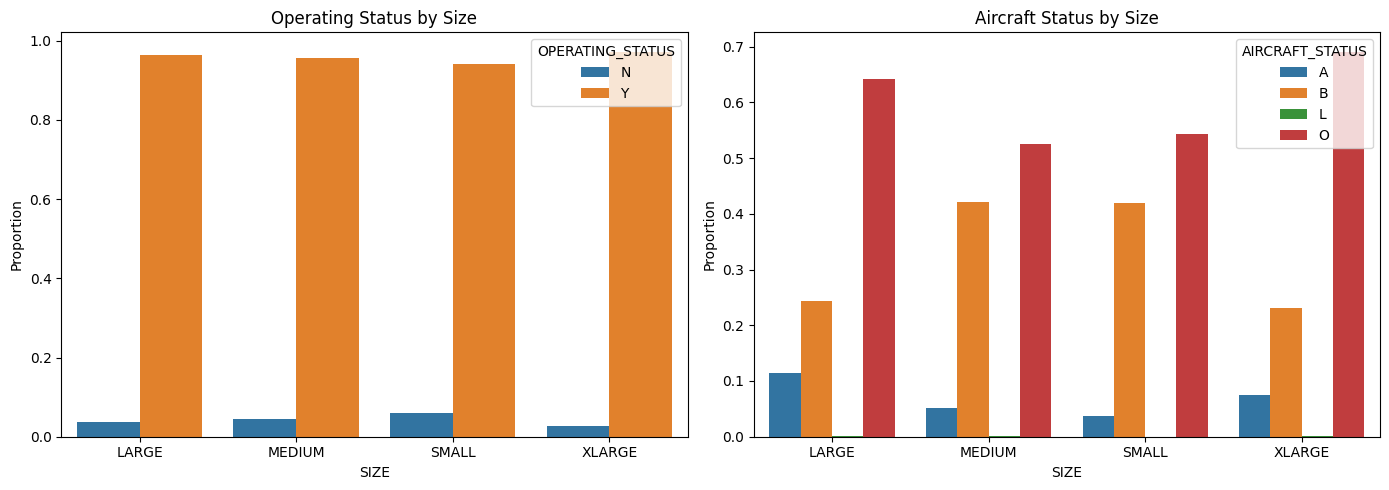

In [277]:
# For each size group, provide and plot the proportions of aircrafts that are operating versus not (OPERATING_STATUS).
# Y - operating
# N - not operating

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

op_props = (inventory.groupby(['SIZE', 'OPERATING_STATUS'], observed=True)
            .size()
            .groupby(level=0)
            .transform(lambda x: x / x.sum())
            .reset_index(name='proportion'))

sns.barplot(data=op_props, x='SIZE', y='proportion',
            hue='OPERATING_STATUS', ax=axes[0])
axes[0].set_title('Operating Status by Size')
axes[0].set_ylabel('Proportion')

ac_props = (inventory.groupby(['SIZE', 'AIRCRAFT_STATUS'], observed=True)
            .size()
            .groupby(level=0)
            .transform(lambda x: x / x.sum())
            .reset_index(name='proportion'))

sns.barplot(data=ac_props, x='SIZE', y='proportion',
            hue='AIRCRAFT_STATUS', ax=axes[1])
axes[1].set_title('Aircraft Status by Size')
axes[1].set_ylabel('Proportion')

plt.tight_layout()
plt.show()


## **6. Modeling Refresher**

In [288]:
# Encoding categorical columns
cat_cols = ['MANUFACTURER','SIZE']

inventory_encoded = inventory.copy()

le = LabelEncoder()
for col in cat_cols:
    mask = inventory_encoded[col].notna()
    inventory_encoded.loc[mask, col] = le.fit_transform(inventory_encoded.loc[mask, col])

In [293]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

seats_features = ['MANUFACTURER', 'SIZE', 'CAPACITY_IN_POUNDS', 'MANUFACTURE_YEAR']
capacity_features = ['MANUFACTURER', 'SIZE', 'NUMBER_OF_SEATS', 'MANUFACTURE_YEAR']

# Safety Net in case any na's are present
seats_df = inventory_encoded.dropna(subset=seats_features + ['NUMBER_OF_SEATS'])
capacity_df = inventory_encoded.dropna(subset=capacity_features + ['CAPACITY_IN_POUNDS'])

In [297]:
#Train/Test Splits

# for NUMBER_OF_SEATS models
X_seats = seats_df[seats_features]
y_seats = seats_df['NUMBER_OF_SEATS']
X_seats_train, X_seats_test, y_seats_train, y_seats_test = train_test_split(
    X_seats, y_seats, test_size=0.2, random_state=42
)

# for CAPACITY_IN_POUNDS models
X_cap = capacity_df[capacity_features]
y_cap = capacity_df['CAPACITY_IN_POUNDS']
X_cap_train, X_cap_test, y_cap_train, y_cap_test = train_test_split(
    X_cap, y_cap, test_size=0.2, random_state=42
)

In [296]:
def rmse(true, pred):
    return np.sqrt(mean_squared_error(true, pred))

results = {}

# 1. LR NUMBER_OF_SEATS
lr_seats = LinearRegression()
lr_seats.fit(X_seats_train, y_seats_train)
results['LR - NUMBER_OF_SEATS'] = {
    'train': rmse(y_seats_train, lr_seats.predict(X_seats_train)),
    'test':  rmse(y_seats_test,  lr_seats.predict(X_seats_test))
}

# 2. LR CAPACITY_IN_POUNDS
lr_cap = LinearRegression()
lr_cap.fit(X_cap_train, y_cap_train)
results['LR - CAPACITY_IN_POUNDS'] = {
    'train': rmse(y_cap_train, lr_cap.predict(X_cap_train)),
    'test':  rmse(y_cap_test,  lr_cap.predict(X_cap_test))
}

# 3. RF NUMBER_OF_SEATS
rf_seats = RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
rf_seats.fit(X_seats_train, y_seats_train)
results['RF - NUMBER_OF_SEATS'] = {
    'train': rmse(y_seats_train, rf_seats.predict(X_seats_train)),
    'test':  rmse(y_seats_test,  rf_seats.predict(X_seats_test))
}

# 4. RF CAPACITY_IN_POUNDS
rf_cap = RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
rf_cap.fit(X_cap_train, y_cap_train)
results['RF - CAPACITY_IN_POUNDS'] = {
    'train': rmse(y_cap_train, rf_cap.predict(X_cap_train)),
    'test':  rmse(y_cap_test,  rf_cap.predict(X_cap_test))
}

print(f"{'Model':<30} {'Train RMSE':>12} {'Test RMSE':>12}")
print("-" * 55)
for name, scores in results.items():
    print(f"{name:<30} {scores['train']:>12.2f} {scores['test']:>12.2f}")

Model                            Train RMSE    Test RMSE
-------------------------------------------------------
LR - NUMBER_OF_SEATS                  60.16        60.18
LR - CAPACITY_IN_POUNDS            87658.53     85438.28
RF - NUMBER_OF_SEATS                   4.04         4.14
RF - CAPACITY_IN_POUNDS            51229.75     51126.15
